# Day 33: Student Performance & Learning Analytics

**Dataset:** `Student_Learning_Analytics_Features.csv`

This notebook is the last of three days in the Student Performance & Learning Analytics
project. It uses the features engineered on Day 32 to build basic prediction models,
evaluates them on held-out data, and compares them against simple baselines.

## 1. Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
)

# Load the dataset with the engineered features from Day 32
df = pd.read_csv("../datasets/Student_Learning_Analytics_Features.csv")

# Preview the data
df.head()

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,...,passed_all_subjects,gender_female,parent_education_rank,race_group_B,race_group_C,race_group_D,race_group_E,attendance_level,engagement_score,high_performer
0,std-01,male,group D,some college,1,1,89,38,85,26,...,0,0,3,0,0,1,0,Medium,-0.594,0
1,std-02,male,group B,high school,1,0,65,100,67,96,...,1,0,2,1,0,0,0,Medium,-0.345,1
2,std-03,male,group C,master's degree,1,0,10,99,97,58,...,0,0,6,0,1,0,0,Medium,0.473,0
3,std-04,male,group D,some college,1,1,22,51,41,84,...,0,0,3,0,0,1,0,Medium,-0.114,0
4,std-05,male,group C,some college,0,1,26,58,64,65,...,0,0,3,0,1,0,0,Low,-0.411,0


In [2]:
print(df.shape)
print("Missing values:", df.isna().sum().sum())

(9991, 28)
Missing values: 0


## 2. Choosing Predictors and Targets

Two prediction tasks come out of the earlier days:

- **Regression:** predict `average_score` (a number) with a linear regression
- **Classification:** predict `high_performer` (1 if the average score is 70 or higher, otherwise 0) with a logistic regression

The predictors are the columns from the "safe to use" rows of the Day 32 table.
`engagement_score` and `attendance_level` are left out on purpose, because they are just
rearranged versions of `attendance_percentage` and `study_hours_per_week`, so they would add
no new information.

In [3]:
predictors = [
    "attendance_percentage", "study_hours_per_week", "test_preparation_course", "lunch",
    "gender_female", "parent_education_rank",
    "race_group_B", "race_group_C", "race_group_D", "race_group_E",
]
target_regression = "average_score"
target_classification = "high_performer"

# Guard against data leakage: no column built from the scores may be a predictor
leaky_columns = [
    "math_score", "reading_score", "writing_score", "science_score", "total_score", "average_score",
    "grade", "best_subject", "weakest_subject", "score_range", "passed_all_subjects", "high_performer",
]
assert not set(predictors) & set(leaky_columns), "A column built from the scores is in the predictors"

print(f"{len(predictors)} predictors, none built from the scores:")
print(predictors)

10 predictors, none built from the scores:
['attendance_percentage', 'study_hours_per_week', 'test_preparation_course', 'lunch', 'gender_female', 'parent_education_rank', 'race_group_B', 'race_group_C', 'race_group_D', 'race_group_E']


## 3. Separating Training and Testing Data

The data is split **once**, 80% for training and 20% for testing, and the test set is not
touched again until each model is evaluated. The split is stratified on `high_performer` so
both sets keep the same share of high performers, and the same split is used for both tasks
so the rows line up.

In [4]:
X = df[predictors]
y_reg = df[target_regression]
y_clf = df[target_classification]

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print(f"High performers in the training set: {y_clf_train.mean() * 100:.1f}%")
print(f"High performers in the test set: {y_clf_test.mean() * 100:.1f}%")

Training set size: 7992
Test set size: 1999
High performers in the training set: 39.0%
High performers in the test set: 39.0%


## 4. Regression Model: Predicting `average_score`

**A baseline first: always predict the training mean**

A model is only useful if it beats the simplest possible guess, so a `DummyRegressor` that
always predicts the average training score is the bar to clear.

In [5]:
baseline_reg = DummyRegressor(strategy="mean")
baseline_reg.fit(X_train, y_reg_train)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_reg_train)

def regression_metrics(model, X_data, y_true):
    pred = model.predict(X_data)
    return {
        "R2": r2_score(y_true, pred),
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
    }

regression_results = pd.DataFrame({
    "Baseline (predict the mean), test": regression_metrics(baseline_reg, X_test, y_reg_test),
    "Linear regression, train": regression_metrics(lin_reg, X_train, y_reg_train),
    "Linear regression, test": regression_metrics(lin_reg, X_test, y_reg_test),
}).T.round(3)

regression_results

,R2,MAE,RMSE
"Baseline (predict the mean), test",-0.000,8.598,10.659
"Linear regression, train",0.288,7.108,8.907
"Linear regression, test",0.271,7.329,9.099


**5-fold cross-validation on the training set, to check that the result is stable**

In [6]:
cv_r2 = cross_val_score(LinearRegression(), X_train, y_reg_train, cv=5, scoring="r2")

print("R2 for each fold:", cv_r2.round(3))
print(f"Mean: {cv_r2.mean():.3f} (std {cv_r2.std():.3f})")

R2 for each fold: [0.257 0.311 0.297 0.281 0.281]
Mean: 0.285 (std 0.018)


**Observation:** the linear regression explains about 27% of the variation in
`average_score` on the test set (R² = 0.27), and its predictions are off by 7.3 points on
average, compared to 8.6 points for simply predicting the mean every time. Training R²
(0.29) and test R² (0.27) are close, and the cross-validation scores stay between 0.26 and
0.31, so the model is not overfitting and the result is stable. The other 73% is unexplained
because a large share of each student's scores is not linked to any of these columns, so
there is a lot of student-to-student variation that attendance, study time, and background
simply cannot capture.

**The model coefficients: points of `average_score` per unit, holding the other predictors fixed**

In [7]:
coef_table = pd.DataFrame({"coefficient": lin_reg.coef_}, index=predictors).round(3)

print("Intercept:", round(lin_reg.intercept_, 2))
coef_table

Intercept: 29.28


,coefficient
attendance_percentage,0.330
study_hours_per_week,1.202
test_preparation_course,-2.543
lunch,0.504
gender_female,4.394
parent_education_rank,-0.038
race_group_B,1.082
race_group_C,0.880
race_group_D,0.625
race_group_E,0.472


**Predicted versus actual scores, and the size of the errors**

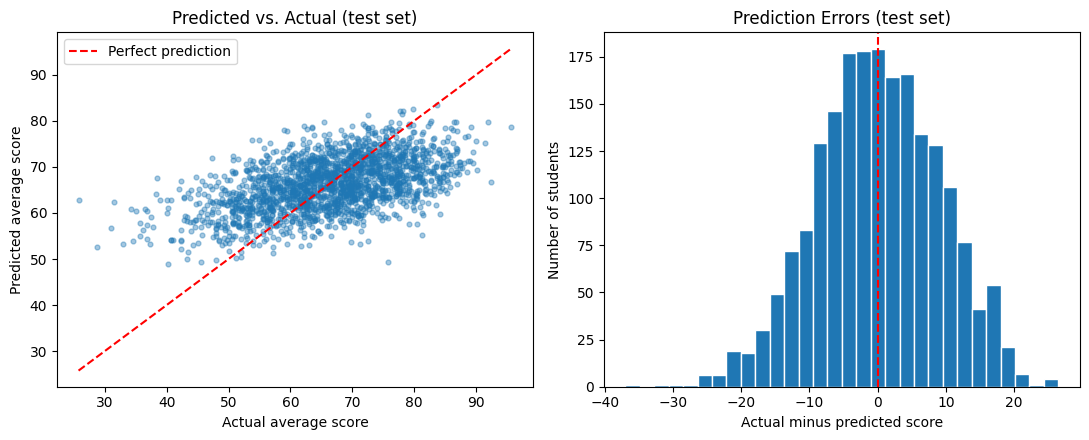

In [8]:
reg_pred = lin_reg.predict(X_test)
residuals = y_reg_test - reg_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_reg_test, reg_pred, alpha=0.4, s=12)
limits = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(limits, limits, color="red", linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual average score")
axes[0].set_ylabel("Predicted average score")
axes[0].set_title("Predicted vs. Actual (test set)")
axes[0].legend()

axes[1].hist(residuals, bins=30, edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Actual minus predicted score")
axes[1].set_ylabel("Number of students")
axes[1].set_title("Prediction Errors (test set)")

plt.tight_layout()
plt.show()

**Observation:** the coefficients say that each extra weekly study hour is worth about 1.2
points of average score, each extra attendance percentage point about 0.33, and female
students score about 4.4 points higher than male students with everything else equal.
`parent_education_rank` is essentially zero (-0.04), and the `race_group` coefficients are
small (0.5 to 1.1 points compared to group A). The predicted-versus-actual plot shows the
model's predictions bunched into a narrower range than the real scores, which is what a
model with an R² of 0.27 looks like: it gets the general direction right but cannot
reproduce the full spread. The errors are centered on zero and roughly bell-shaped, so the
model is not systematically over- or under-predicting.

**Why is the `test_preparation_course` coefficient negative?**

A negative coefficient looks like the course hurts performance, so it deserves a closer look
before anyone believes it.

In [9]:
# On its own, how does the course relate to average score?
course_only = LinearRegression().fit(X_train[["test_preparation_course"]], y_reg_train)
print(f"Course coefficient on its own: {course_only.coef_[0]:+.2f} points")

# How do study hours differ between students with and without the course?
hours_by_course = df.groupby("test_preparation_course")["study_hours_per_week"].mean().round(2)
print("\nAverage study hours per week by course (0 = no, 1 = yes):")
print(hours_by_course)

Course coefficient on its own: +0.89 points

Average study hours per week by course (0 = no, 1 = yes):
test_preparation_course
0    6.03
1    8.60
Name: study_hours_per_week, dtype: float64


**Observation:** on its own, taking the course goes with a gain of only +0.9 points, but in
the full model its coefficient is -2.5. The reason is how `study_hours_per_week` was
simulated on Day 31: students who took the course were given about 2.6 extra study hours.
The model credits those hours to `study_hours_per_week`, and since the course itself had
almost no direct link to scores, it subtracts most of that credit back through the course
coefficient. This does **not** mean the course hurts performance. It is a reminder that
coefficients depend on which other predictors are in the model, and that two overlapping
predictors can produce misleading signs.

## 5. Classification Model: Predicting `high_performer`

**A baseline first: always predict the most common class**

In [10]:
baseline_clf = DummyClassifier(strategy="most_frequent")
baseline_clf.fit(X_train, y_clf_train)

# Scaling is fitted on the training data only, inside the pipeline
log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_reg.fit(X_train, y_clf_train)

def classification_metrics(model, X_data, y_true):
    pred = model.predict(X_data)
    proba = model.predict_proba(X_data)[:, 1]
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, proba),
    }

classification_results = pd.DataFrame({
    "Baseline (most common class), test": classification_metrics(baseline_clf, X_test, y_clf_test),
    "Logistic regression, train": classification_metrics(log_reg, X_train, y_clf_train),
    "Logistic regression, test": classification_metrics(log_reg, X_test, y_clf_test),
}).T.round(3)

classification_results

,Accuracy,Precision,Recall,F1,ROC AUC
"Baseline (most common class), test",0.610,0.000,0.000,0.000,0.500
"Logistic regression, train",0.691,0.633,0.491,0.553,0.739
"Logistic regression, test",0.687,0.625,0.492,0.550,0.735


**5-fold cross-validation accuracy on the training set**

In [11]:
cv_acc = cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), X_train, y_clf_train, cv=5
)

print("Accuracy for each fold:", cv_acc.round(3))
print(f"Mean: {cv_acc.mean():.3f} (std {cv_acc.std():.3f})")

Accuracy for each fold: [0.675 0.694 0.686 0.691 0.69 ]
Mean: 0.687 (std 0.007)


**Confusion matrix and ROC curve on the test set**

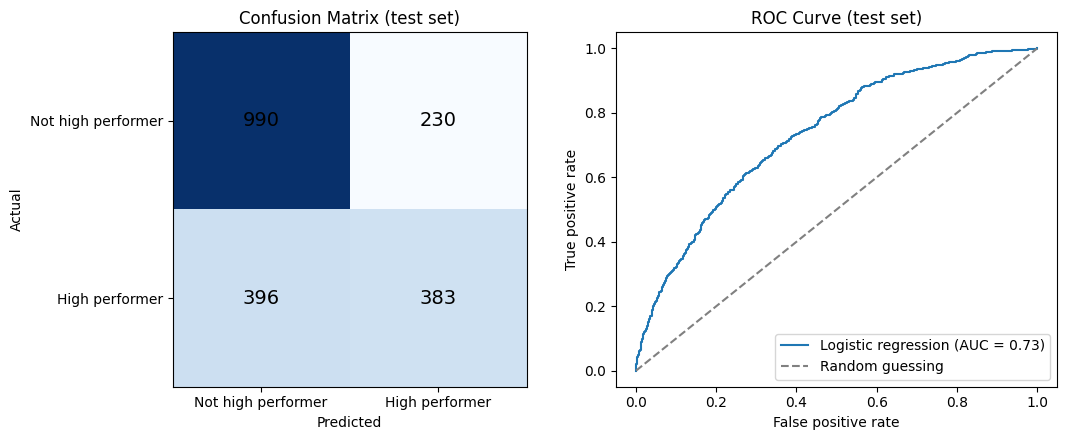

In [12]:
clf_pred = log_reg.predict(X_test)
clf_proba = log_reg.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_clf_test, clf_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Not high performer", "High performer"])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["Not high performer", "High performer"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix (test set)")

fpr, tpr, _ = roc_curve(y_clf_test, clf_proba)
axes[1].plot(fpr, tpr, label=f"Logistic regression (AUC = {roc_auc_score(y_clf_test, clf_proba):.2f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guessing")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC Curve (test set)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Observation:** the logistic regression reaches 68.7% accuracy on the test set, compared to
61.0% for always predicting "not a high performer", and its ROC AUC is 0.73 (0.5 would be
random guessing). That is a real improvement, but a modest one. The cross-validation
accuracy stays between 67.5% and 69.4%, so it is stable and not overfit. The confusion
matrix shows where the model struggles: of the 779 students who are really high performers,
it finds 383 (a recall of 49%) and misses 396, and of the 613 students it flags as high
performers, 62% truly are (precision). At the default 0.5 cutoff the model is cautious about
handing out the high-performer label, so it misses about half of the real high performers.
Lowering the cutoff would catch more of them at the cost of more false alarms, the same
trade-off explored with threshold tuning earlier in the internship.

**The logistic regression coefficients (on standardized predictors, so they can be compared directly)**

In [13]:
logit_coefs = pd.DataFrame(
    {"standardized_coefficient": log_reg.named_steps["logisticregression"].coef_[0]},
    index=predictors,
).round(3)

logit_coefs.sort_values("standardized_coefficient", ascending=False)

,standardized_coefficient
study_hours_per_week,0.634
attendance_percentage,0.579
gender_female,0.338
race_group_B,0.088
race_group_C,0.084
race_group_D,0.057
race_group_E,0.040
lunch,0.038
parent_education_rank,-0.014
test_preparation_course,-0.240


**Observation:** the two engagement predictors have the largest effects on the odds of being
a high performer: `study_hours_per_week` (0.63) and `attendance_percentage` (0.58), followed
by `gender_female` (0.34). Everything else is small. The same caution as before applies:
attendance and study hours were simulated with a built-in link to performance, so their
prominence here is by construction.

## 6. Does a More Flexible Model Help?

A random forest can capture non-linear patterns and interactions that a linear or logistic
model cannot. If the relationships in the data were complicated, it should beat the simple
models, so both tasks are repeated with a random forest as a check.

In [14]:
rf_reg = RandomForestRegressor(n_estimators=200, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)

rf_clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_clf_train)

model_comparison = pd.DataFrame({
    "Regression R2 (test)": [
        r2_score(y_reg_test, lin_reg.predict(X_test)), r2_score(y_reg_test, rf_reg.predict(X_test)),
    ],
    "Regression MAE (test)": [
        mean_absolute_error(y_reg_test, lin_reg.predict(X_test)), mean_absolute_error(y_reg_test, rf_reg.predict(X_test)),
    ],
    "Classification accuracy (test)": [
        accuracy_score(y_clf_test, log_reg.predict(X_test)), accuracy_score(y_clf_test, rf_clf.predict(X_test)),
    ],
    "Classification ROC AUC (test)": [
        roc_auc_score(y_clf_test, log_reg.predict_proba(X_test)[:, 1]), roc_auc_score(y_clf_test, rf_clf.predict_proba(X_test)[:, 1]),
    ],
}, index=["Linear / logistic regression", "Random forest"]).round(3)

model_comparison

,Regression R2 (test),Regression MAE (test),Classification accuracy (test),Classification ROC AUC (test)
Linear / logistic regression,0.271,7.329,0.687,0.735
Random forest,0.264,7.313,0.692,0.732


**Observation:** the random forest performs about the same as the simple models (test R² of
0.26 versus 0.27, and accuracy of 69.2% versus 68.7%), and differences that small are within
noise, so the extra complexity is not worth it. That fits how the data behaves: the
relationships are simple and roughly linear, and what is left over is random variation that
no model can predict. Linear and logistic regression are therefore the better choice here,
since they perform just as well and their coefficients can actually be read and explained.

## Outcome

This notebook finished the Student Performance & Learning Analytics project by building and
evaluating prediction models on the features from Day 32. After checking that no column
built from the scores was used as a predictor, the data was split once into 7,992 training
and 1,999 test students. A linear regression predicting `average_score` reached a test R² of
0.27 and a mean absolute error of 7.3 points (versus 8.6 for the mean baseline), and a
logistic regression predicting `high_performer` reached 68.7% accuracy and a ROC AUC of 0.73
(versus 61.0% accuracy for the majority-class baseline). Cross-validation showed both
results were stable, and a random forest performed about the same, so the simpler models
were kept. The models beat their baselines but explain only part of the variation: the
logistic regression finds about 49% of the real high performers, because most of what drives
a student's scores is not captured by attendance, study time, and background. The
coefficients pointed to study hours, attendance, and gender as the main drivers, while the
negative coefficient on the test preparation course turned out to come from overlap with the
simulated study hours rather than a real effect. As with the earlier days, the attendance
and study-hour results are partly built in by the simulation, so the models show the
modeling workflow rather than real findings about students.